<a href="https://colab.research.google.com/github/LeoSuzu/Bitcoin_Analysis_And_Prediction/blob/main/Copy_of_bitcoin_predict_LSTM_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin Price Prediction using LSTM and CNN Models
## Deep Learning Forecasting for Cryptocurrency

**Author:** Leo Suzuki  
**Institution:** Tampere University of Applied Sciences  
**Year:** 2026  

---

### 🚀 How to Run This Notebook

This notebook is designed to run automatically from top to bottom, dynamically fetching live market data and training neural networks on the fly. No static CSV files are required.

#### 1. Install Required Libraries
Ensure the first code cell is executed before running the rest of the script. This installs the necessary APIs and Machine Learning frameworks:
`!pip install yfinance scikit-learn tensorflow plotly`

#### 2. Execute the Code
Run the remaining cells sequentially.

**What happens automatically behind the scenes:**
* **Live Data Fetching:** The script connects to the Yahoo Finance API (`yfinance`) to pull the most recent 5 years of daily Bitcoin (BTC-USD) prices.
* **Data Preprocessing:** The data is automatically scaled using `MinMaxScaler` and formatted into 60-day sliding windows for deep learning.
* **Model Training:** Two advanced neural networks (LSTM and 1D CNN) are built, compiled, and trained on the fetched dataset.
* **Forecasting & Visualization:** Both models predict the next 30 days of price action, generating interactive `plotly` charts to compare their performance and future outlooks.

---

### 🛠 Libraries Used

The following core libraries power this notebook:

- `yfinance` (Live stock data API)
- `pandas` & `numpy` (Data manipulation & array formatting)
- `scikit-learn` (Data scaling and error metrics like RMSE/R²)
- `tensorflow` & `keras` (Building and training the Deep Learning models)
- `plotly` & `matplotlib` (Interactive and static visualizations)

---


# Importing necessary libraries

In [33]:
# Install missing library (Run this cell first!)
!pip install yfinance

# Data manipulation and dynamic fetching libraries
import pandas as pd
import numpy as np
import datetime as dt
import yfinance as yf

# Evaluation libraries for model
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                             r2_score, explained_variance_score, mean_poisson_deviance, mean_gamma_deviance)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Model building libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Visualization libraries
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display

# Data check

In [34]:
# 1. Dynamic Timeframe Setup
current_year = dt.datetime.now().year
end_year = current_year - 1
start_year = end_year - 5

start_date = f"{start_year}-01-01"
end_date = f"{current_year}-01-01"

print(f"Fetching BTC-USD data from {start_date} to {end_year}-12-31...")

# 2. Download data directly
main_df = yf.download('BTC-USD', start=start_date, end=end_date)

if isinstance(main_df.columns, pd.MultiIndex):
    main_df.columns = main_df.columns.droplevel(1)

main_df.reset_index(inplace=True) # Now 'Date' is a simple, standard column

# 3. Check for missing values
if main_df.isnull().sum().sum() == 0:
    print('No missing values found in fetched data.')
else:
    print('There are missing values, dropping them...')
    main_df = main_df.dropna()

# 4. Prepare the Close Data
close_df = main_df.loc[:, ['Date', 'Close']].copy() # Added .copy() to prevent warnings
close_df['Date'] = pd.to_datetime(close_df['Date'])

# Print total data amount for prediction
print(f"Total data for prediction ({start_year}-{end_year}): ", close_df.shape[0])

# 5. Plot the Considered Period (Pro Candlestick Chart)
# Adding .squeeze() forces the yfinance data into the flat 1D lists Plotly requires
fig = go.Figure(data=[go.Candlestick(
    x=main_df['Date'].squeeze(),
    open=main_df['Open'].squeeze(),
    high=main_df['High'].squeeze(),
    low=main_df['Low'].squeeze(),
    close=main_df['Close'].squeeze(),
    increasing_line_color='green',
    decreasing_line_color='red'
)])

fig.update_layout(
    title=f'Bitcoin Candlestick Chart ({start_year}-{end_year})',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    xaxis_rangeslider_visible=True
)

fig.show()

/tmp/ipykernel_824/251833941.py:12: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Fetching BTC-USD data from 2020-01-01 to 2025-12-31...
No missing values found in fetched data.
Total data for prediction (2020-2025):  2192


# Data preparation for training

In [35]:
# Delete the "Date" column from the DataFrame
del close_df['Date']

# Initialize MinMaxScaler with a feature range from 0 to 1
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape the "Close" column to a 2D array (required by MinMaxScaler) and normalize the data
scaled_data = scaler.fit_transform(np.array(close_df).reshape(-1, 1))

# Split the data into training and testing sets (80% training and 20% testing)
# Shuffle is set to False because data must remain in chronological order
train_data, test_data = train_test_split(scaled_data, test_size=0.2, shuffle=False)

# Check print for datasets
print("Train data shape:", train_data.shape)
print("Test data shape:", test_data.shape)

# Function to create a dataset for time-series forecasting
def create_dataset(dataset, time_step=1):
    """
    Function to create a dataset for time-series forecasting.

    Args:
    - dataset: Input time-series data as a 2D numpy array.
    - time_step: Number of time steps to look back in the past.

    Returns:
    - data_x: Input sequences (shape: time_step, num_features).
    - data_y: Target values corresponding to each input sequence.
    """
    data_x, data_y = [], []

    # FIX: Removed the extra '- 1' to ensure we capture the final day in the dataset
    for i in range(len(dataset) - time_step):
        a = dataset[i:(i + time_step), 0]
        data_x.append(a)
        data_y.append(dataset[i + time_step, 0])

    return np.array(data_x), np.array(data_y)

# Transform the Close price based on forecasting requirement
# 60 days gives the model roughly 2 months of historical context to predict tomorrow
time_step = 60

# Create the dataset with the updated time step
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)

print("--- Initial Shapes ---")
print("X_train shape: ", X_train.shape)
print("y_train shape: ", y_train.shape)
print("X_test shape:  ", X_test.shape)
print("y_test shape:  ", y_test.shape)

# Reshape input to be [samples, time steps, features] which is required for LSTM and CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("\n--- Reshaped for Neural Networks ---")
print("X_train shape: ", X_train.shape)
print("X_test shape:  ", X_test.shape)

# Split training data again to create a validation set (10% of training data)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, shuffle=False)

print(f"Final Train shape: {X_train.shape}")
print(f"Validation shape:  {X_val.shape}")
print(f"Test shape:        {X_test.shape}")

Train data shape: (1753, 1)
Test data shape: (439, 1)
--- Initial Shapes ---
X_train shape:  (1693, 60)
y_train shape:  (1693,)
X_test shape:   (379, 60)
y_test shape:   (379,)

--- Reshaped for Neural Networks ---
X_train shape:  (1693, 60, 1)
X_test shape:   (379, 60, 1)
Final Train shape: (1523, 60, 1)
Validation shape:  (170, 60, 1)
Test shape:        (379, 60, 1)


# LSTM model training

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0075 - val_loss: 0.0013
Epoch 2/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 3/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 4/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0012 - val_loss: 0.0010
Epoch 5/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 6/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.0011 - val_loss: 0.0021
Epoch 7/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0011 - val_loss: 9.6544e-04
Epoch 8/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0010 - val_loss: 0.0021
Epoch 9/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 9.7092e-04 - val_loss: 8.7598e-04
Epoch 10/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 9.6403e-04 - val_loss: 0.0010
Epoch 11/120
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 8.0989e-04 - val_loss: 0.0014
Epoch 12/120
48/48 ━━━━━━━━━━━━━

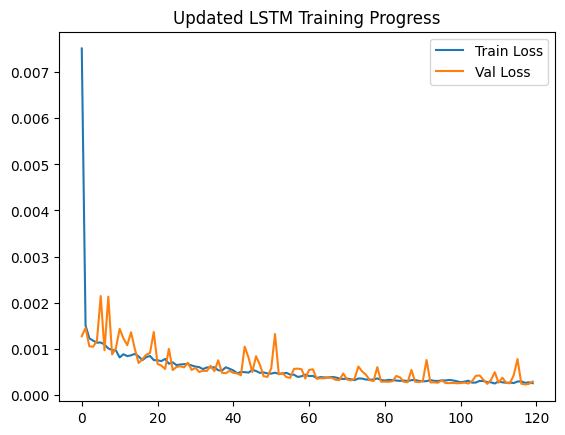

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 60, 128)        │        66,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385,253 (1.47 MB)

 Trainable params: 128,417 (501.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 256,836 (1003.27 KB)

None


In [36]:
# LSTM model with higher sensitivity
lstm_model = Sequential()

# Layer 1: Increased units to 128
lstm_model.add(LSTM(128, input_shape=(time_step, 1), return_sequences=True))
lstm_model.add(Dropout(0.15))

# Layer 2: Intermediate processing
lstm_model.add(LSTM(64, return_sequences=True))
lstm_model.add(Dropout(0.15))

# Layer 3: Final sequence processing
lstm_model.add(LSTM(32, return_sequences=False))
lstm_model.add(Dropout(0.1))

# Output Layer
lstm_model.add(Dense(1))

# Compile with a slightly more conservative learning rate for deeper layers
optimizer = Adam(learning_rate=0.0005)
lstm_model.compile(loss='mean_squared_error', optimizer=optimizer)

# Train the model
history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=120,
    batch_size=32,
    verbose=1
)

# Evaluate
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Updated LSTM Training Progress')
plt.legend()
plt.show()

print(lstm_model.summary())

# LSTM Model Evaluation & Visualization

In [37]:
# 1. Make predictions using the trained LSTM model
train_predict = lstm_model.predict(X_train)
test_predict = lstm_model.predict(X_test)

# 2. Transform back to original price (USD)
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)
original_y_train = scaler.inverse_transform(y_train.reshape(-1,1))
original_y_test = scaler.inverse_transform(y_test.reshape(-1,1))

# 3. Calculate metrics for the final comparison later
rmse_train_lstm = np.sqrt(mean_squared_error(original_y_train, train_predict))
rmse_test_lstm = np.sqrt(mean_squared_error(original_y_test, test_predict))

# Print core regression scores
print(f"Train R-squared Score (LSTM): {r2_score(original_y_train, train_predict):.4f}")
print(f"Test R-squared Score (LSTM):  {r2_score(original_y_test, test_predict):.4f}")
print("\n------------------------------------\n")

# 4. Prepare data for the Comparison Chart
# We use np.nan so that the lines only appear where the predictions actually exist
trainPredictPlot = np.empty((len(scaled_data), 1))
trainPredictPlot[:, :] = np.nan
# Train predictions start at 'time_step'
trainPredictPlot[time_step:len(train_predict)+time_step, :] = train_predict

testPredictPlot = np.empty((len(scaled_data), 1))
testPredictPlot[:, :] = np.nan
# Test predictions start after the training data + validation slice + time_steps
# This logic ensures the test line starts exactly where the test data begins
test_start_idx = len(scaled_data) - len(test_predict)
testPredictPlot[test_start_idx:, :] = test_predict

# 5. Create a combined DataFrame for Plotly (FIXED for MultiIndex)
# We use .squeeze() to ensure every column is 1-dimensional
plotdf = pd.DataFrame({
    'date': main_df['Date'].squeeze(),
    'original_close': main_df['Close'].squeeze(),
    'train_predicted': trainPredictPlot.flatten(),
    'test_predicted': testPredictPlot.flatten()
})

# 6. Plot the comparison
from itertools import cycle
names = cycle(['Original Close Price', 'Train Prediction (LSTM)', 'Test Prediction (LSTM)'])

fig = px.line(plotdf, x='date',
              y=['original_close', 'train_predicted', 'test_predicted'],
              labels={'value': 'Price (USD)', 'date': 'Date', 'variable': 'Type'},
              title='Historical vs. Predicted Bitcoin Price (LSTM Evaluation)',
              template='plotly_dark')

fig.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig.for_each_trace(lambda t: t.update(name = next(names)))

fig.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Train R-squared Score (LSTM): 0.9923
Test R-squared Score (LSTM):  0.8565

------------------------------------



# LSTM Predicting the future 30 days ahead

In [38]:
# 1. Generate the 14-day forecast
last_60_days = scaled_data[-60:]
current_input = last_60_days.reshape(1, time_step, 1)
future_predictions_scaled = []

forecast_days = 14 # Define forecast duration here

for i in range(forecast_days):
    next_day_pred = lstm_model.predict(current_input, verbose=0)
    future_predictions_scaled.append(next_day_pred[0])
    current_input = np.append(current_input[:, 1:, :], [next_day_pred], axis=1)

future_predictions = scaler.inverse_transform(future_predictions_scaled).flatten()

# 2. Setup Dates
last_date = main_df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

# 3. Setup Historical Data for the plot (last `time_step` days for context)
history_subset = main_df.tail(time_step).copy() # Showing last 60 days of history
history_dates = history_subset['Date'].values
history_prices = history_subset['Close'].values.flatten()

# 4. Create the Figure
fig = go.Figure()

# Add Historical Trace (Orange)
fig.add_trace(go.Scatter(
    x=history_dates,
    y=history_prices,
    mode='lines',
    name='Actual Historical',
    line=dict(color='orange', width=3)
))

# Add Forecast Trace (Green)
# Note: We prepend the last historical price/date to make them touch
fig.add_trace(go.Scatter(
    x=np.append(history_dates[-1], future_dates),
    y=np.append(history_prices[-1], future_predictions),
    mode='lines',
    name='Future Forecast',
    line=dict(color='#00FF00', width=3, dash='dot') # Dashed green for the future
))

# 5. Add a "Today" Marker
fig.add_vline(x=last_date, line_width=2, line_dash="dash", line_color="white")

# 6. Update Layout
fig.update_layout(
    title=f'Bitcoin: {forecast_days}-Day Price Prediction (LSTM)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified'
)

fig.show()

#  LSTM Big Picture - Last Year + 30-Day Forecast

In [39]:
# 1. Grab the last year of real data (365 days)
# We use .copy() and .reset_index() to ensure a clean slate
big_history = main_df.tail(365).copy().reset_index(drop=True)
hist_dates = big_history['Date'].values
hist_prices = big_history['Close'].values.flatten()

# 2. Setup the Forecast Data (already calculated from previous step)
last_date = big_history['Date'].iloc[-1]
forecast_days = 14 # Ensure forecast_days is defined here or globally
# Ensure future_predictions is a flat 1D array
forecast_prices = future_predictions.flatten()
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

# 3. Create the Figure
fig_big = go.Figure()

# Add the Historical Line (Last 1 Year)
fig_big.add_trace(go.Scatter(
    x=hist_dates,
    y=hist_prices,
    mode='lines',
    name='Actual History (Last Year)',
    line=dict(color='orange', width=2)
))

# Add the Forecast Line (14 Days)
# We start this trace at the last point of history to connect them
fig_big.add_trace(go.Scatter(
    x=np.append(hist_dates[-1], future_dates),
    y=np.append(hist_prices[-1], forecast_prices),
    mode='lines',
    name=f'{forecast_days}-Day LSTM Forecast',
    line=dict(color='#00FF00', width=3)
))

# 4. Final Polish
fig_big.update_layout(
    title=f'Bitcoin: 1-Year Historical Trend and {forecast_days}-Day Forecast ({last_date.year})',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True)) # Adds the slider back for zooming
)

fig_big.show()

# CNN model training

Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



48/48 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 0.1880 - val_loss: 0.1513
Epoch 2/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0121 - val_loss: 0.0979
Epoch 3/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0056 - val_loss: 0.0931
Epoch 4/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0811
Epoch 5/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0045 - val_loss: 0.0636
Epoch 6/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0048 - val_loss: 0.0777
Epoch 7/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0041 - val_loss: 0.0588
Epoch 8/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0037 - val_loss: 0.0468
Epoch 9/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0038 - val_loss: 0.0645
Epoch 10/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - val_loss: 0.0504
Epoch 11/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0029 - val_loss: 0.0351
Epoch 12/100
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0034 - val_l

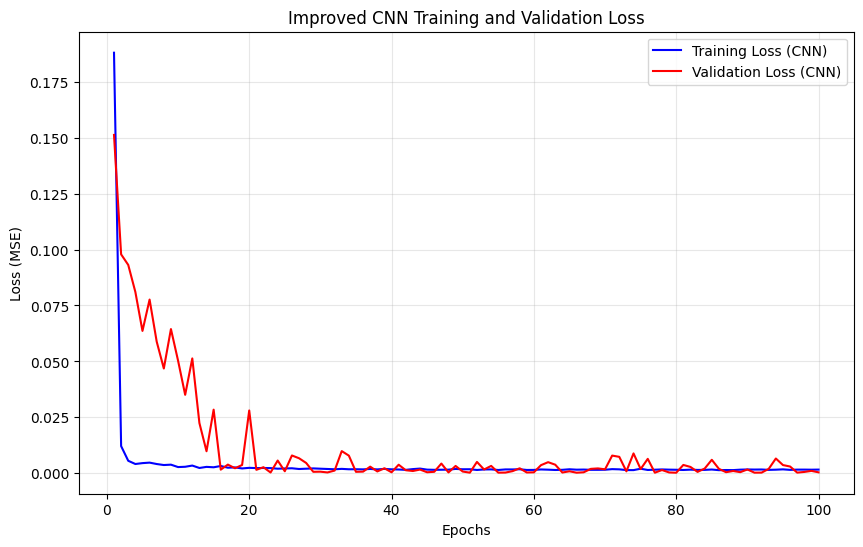


--- Improved CNN Model Architecture Summary ---


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_7 (Conv1D)               │ (None, 58, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 58, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 29, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1856)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 50)             │        92,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 279,985 (1.07 MB)

 Trainable params: 93,285 (364.39 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 186,572 (728.80 KB)

In [52]:
# 1. Build the Improved CNN Model Architecture (Revised for better performance)
cnn_model = Sequential()

# Layer 1: Simpler, smaller kernel to capture local patterns
cnn_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling1D(pool_size=2)) # Reduce sequence length by half

# Layer 2: Deeper but still simplified analysis
cnn_model.add(Flatten()) # Flatten remaining features
cnn_model.add(Dense(50, activation='relu')) # Reduced dense units
cnn_model.add(Dropout(0.3)) # Increased dropout for regularization
cnn_model.add(Dense(1))

# Compile: Slightly adjusted learning rate
optimizer = Adam(learning_rate=0.0008) # Adjusted learning rate
cnn_model.compile(loss='mean_squared_error', optimizer=optimizer)

# Train: Reduce epochs as it's a simpler model, faster convergence expected
history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, # Reduced epochs
    batch_size=32,
    verbose=1
)

# 4. Evaluate the Training History
loss_cnn = history_cnn.history['loss']
val_loss_cnn = history_cnn.history['val_loss']
epochs_range = range(1, len(loss_cnn) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_range, loss_cnn, 'b', label='Training Loss (CNN)')
plt.plot(epochs_range, val_loss_cnn, 'r', label='Validation Loss (CNN)')
plt.title('Improved CNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Model Summary
print("\n--- Improved CNN Model Architecture Summary ---")
cnn_model.summary()

# CNN Model Evalution & Visualization

In [53]:
# 1. Make predictions
train_predict_cnn = cnn_model.predict(X_train)
test_predict_cnn  = cnn_model.predict(X_test)

# 2. Invert scaling
train_predict_cnn = scaler.inverse_transform(train_predict_cnn)
test_predict_cnn  = scaler.inverse_transform(test_predict_cnn)
original_y_train_cnn = scaler.inverse_transform(y_train.reshape(-1, 1))
original_y_test_cnn  = scaler.inverse_transform(y_test.reshape(-1, 1))

# 3. Calculate Performance Metrics
rmse_test_cnn = np.sqrt(mean_squared_error(original_y_test_cnn, test_predict_cnn))
r2_test_cnn = r2_score(original_y_test_cnn, test_predict_cnn)

print(f"Test RMSE (CNN): {rmse_test_cnn:.2f}")
print(f"Test R-squared Score (CNN): {r2_test_cnn:.4f}")

# 4. Prepare Arrays for Plotting
# Initialize with NaNs so only predicted sections show up
trainPredictPlot_cnn = np.empty((len(scaled_data), 1))
trainPredictPlot_cnn[:, :] = np.nan
trainPredictPlot_cnn[time_step : len(train_predict_cnn) + time_step, :] = train_predict_cnn

testPredictPlot_cnn = np.empty((len(scaled_data), 1))
testPredictPlot_cnn[:, :] = np.nan
# Align the test line to the very end of the dataset
test_start_idx_cnn = len(scaled_data) - len(test_predict_cnn)
testPredictPlot_cnn[test_start_idx_cnn:, :] = test_predict_cnn

# 5. Create DataFrame (Using .squeeze() for 1D safety)
plotdf_cnn = pd.DataFrame({
    'date': main_df['Date'].squeeze(),
    'original_close': main_df['Close'].squeeze(),
    'train_predicted': trainPredictPlot_cnn.flatten(),
    'test_predicted': testPredictPlot_cnn.flatten()
})

# 6. Plot the CNN Comparison
from itertools import cycle
cnn_names = cycle(['Original Close Price', 'Train Prediction (CNN)', 'Test Prediction (CNN)'])

fig_cnn = px.line(plotdf_cnn, x='date',
                  y=['original_close', 'train_predicted', 'test_predicted'],
                  labels={'value': 'Price (USD)', 'date': 'Date', 'variable': 'Type'},
                  title='Historical vs. Predicted Bitcoin Price (CNN Evaluation)',
                  template='plotly_dark')

fig_cnn.update_layout(xaxis=dict(rangeslider=dict(visible=True)))
fig_cnn.for_each_trace(lambda t: t.update(name = next(cnn_names)))

fig_cnn.show()

48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Test RMSE (CNN): 5366.39
Test R-squared Score (CNN): 0.7851


# CNN Predicting the future 30 days ahead

In [54]:
# 1. Generate the 14-day forecast (Sliding Window)
last_60_days_cnn = scaled_data[-60:]
current_input_cnn = last_60_days_cnn.reshape(1, time_step, 1)
future_predictions_scaled_cnn = []

forecast_days = 14 # Ensure forecast_days is defined here or globally

for i in range(forecast_days):
    next_day_pred_cnn = cnn_model.predict(current_input_cnn, verbose=0)
    future_predictions_scaled_cnn.append(next_day_pred_cnn[0])
    current_input_cnn = np.append(current_input_cnn[:, 1:, :], [next_day_pred_cnn], axis=1)

# Inverse transform to real USD prices
future_predictions_cnn = scaler.inverse_transform(future_predictions_scaled_cnn).flatten()

# 2. Setup Dates and Historical Data
last_date = main_df['Date'].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=forecast_days)

# Get last `time_step` days of history for context
history_subset = main_df.tail(time_step).copy()
history_dates = history_subset['Date'].values
history_prices = history_subset['Close'].values.flatten()

# 3. Create the Figure manually
fig_cnn_final = go.Figure()

# Add Historical Trace (Orange)
fig_cnn_final.add_trace(go.Scatter(
    x=history_dates,
    y=history_prices,
    mode='lines',
    name='Actual Historical',
    line=dict(color='orange', width=3)
))

# Add CNN Forecast Trace (Cyan)
# We prepend the last history point to ensure the lines touch
fig_cnn_final.add_trace(go.Scatter(
    x=np.append(history_dates[-1], future_dates),
    y=np.append(history_prices[-1], future_predictions_cnn),
    mode='lines',
    name='CNN Future Forecast',
    line=dict(color='#00FFFF', width=3, dash='dot')
))

# 4. Add "Today" Marker and Layout
fig_cnn_final.add_vline(x=last_date, line_width=2, line_dash="dash", line_color="white")

fig_cnn_final.update_layout(
    title=f'Bitcoin: Recent History & {forecast_days}-Day CNN Future Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified'
)

fig_cnn_final.show()

# CNN Big Picture - 1 Year History + 30 Day Forecast

In [55]:
# 1. Grab the last year of real data (365 days)
# Using a clean copy to avoid any slice warnings
big_history_cnn = main_df.tail(365).copy().reset_index(drop=True)
hist_dates_cnn = big_history_cnn['Date'].values
hist_prices_cnn = big_history_cnn['Close'].values.flatten()

# 2. Setup the Forecast Data (using the future_predictions_cnn from the last step)
last_date_cnn = big_history_cnn['Date'].iloc[-1]
forecast_days = 14 # Ensure forecast_days is defined here or globally
future_dates_cnn = pd.date_range(start=last_date_cnn + pd.Timedelta(days=1), periods=forecast_days)

# 3. Create the Figure
fig_big_cnn = go.Figure()

# Add the Historical Line (Last 1 Year) - Orange
fig_big_cnn.add_trace(go.Scatter(
    x=hist_dates_cnn,
    y=hist_prices_cnn,
    mode='lines',
    name='Actual History (Last Year)',
    line=dict(color='orange', width=2)
))

# Add the CNN Forecast Line (14 Days) - Cyan
# We connect it to the last historical point
fig_big_cnn.add_trace(go.Scatter(
    x=np.append(hist_dates_cnn[-1], future_dates_cnn),
    y=np.append(hist_prices_cnn[-1], future_predictions_cnn),
    mode='lines',
    name=f'{forecast_days}-Day CNN Forecast',
    line=dict(color='#00FFFF', width=3)
))

# 4. Final Layout and Range Slider
fig_big_cnn.update_layout(
    title=f'Bitcoin: 1-Year Trend and {forecast_days}-Day CNN Prediction ({last_date_cnn.year})',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified',
    xaxis=dict(rangeslider=dict(visible=True))
)

fig_big_cnn.show()

# Statistical Comparison (LSTM vs CNN)

In [56]:
# 1. Quickly calculate the missing metrics for LSTM
mse_test_lstm = mean_squared_error(original_y_test, test_predict)
mae_test_lstm = mean_absolute_error(original_y_test, test_predict)
r2_test_lstm = r2_score(original_y_test, test_predict)

# 2. Quickly calculate the missing metrics for CNN
mse_test_cnn = mean_squared_error(original_y_test_cnn, test_predict_cnn)
mae_test_cnn = mean_absolute_error(original_y_test_cnn, test_predict_cnn)
# (RMSE and R2 for CNN were already saved as rmse_test_cnn and r2_test_cnn)

# 3. Create the comparison dictionary
comparison_data = {
    'Metric': ['RMSE (Root Mean Square Error)', 'MSE (Mean Square Error)', 'MAE (Mean Absolute Error)', 'R-squared Score'],
    'LSTM Model': [rmse_test_lstm, mse_test_lstm, mae_test_lstm, r2_test_lstm],
    'CNN Model': [rmse_test_cnn, mse_test_cnn, mae_test_cnn, r2_test_cnn]
}

# 4. Create and display the DataFrame
comparison_df = pd.DataFrame(comparison_data)

# Optional: Format the numbers so they are easier to read (no scientific notation)
pd.options.display.float_format = '{:,.2f}'.format

print("--- Numerical Performance Comparison ---")
display(comparison_df)

# Print a quick summary of the winner based on RMSE
winner = "LSTM" if rmse_test_lstm < rmse_test_cnn else "CNN"
print(f"\nBased on RMSE (lowest error), the {winner} model performed better on the test data.")

--- Numerical Performance Comparison ---


,Metric,LSTM Model,CNN Model
0,RMSE (Root Mean Square Error),"4,384.95","5,366.39"
1,MSE (Mean Square Error),"19,227,743.62","28,798,126.42"
2,MAE (Mean Absolute Error),"3,804.49","4,749.03"
3,R-squared Score,0.86,0.79



Based on RMSE (lowest error), the LSTM model performed better on the test data.


# Head-to-Head Battle (60 Days History + Both Forecasts)

In [57]:
# 1. Grab exactly the last 60 days of real data
history_60 = main_df.tail(60).copy().reset_index(drop=True)
h60_dates = history_60['Date'].values
h60_prices = history_60['Close'].values.flatten()

forecast_days = 14 # Ensure forecast_days is defined here or globally
future_dates = pd.date_range(start=history_60['Date'].iloc[-1] + pd.Timedelta(days=1), periods=forecast_days)

# (We already have future_dates, future_predictions (LSTM), and future_predictions_cnn from previous blocks)

# 2. Create the Figure
fig_battle = go.Figure()

# 3. Add the Historical Trace (Orange)
fig_battle.add_trace(go.Scatter(
    x=h60_dates,
    y=h60_prices,
    mode='lines',
    name='Actual History (Last 60 Days)',
    line=dict(color='orange', width=3)
))

# 4. Add the LSTM Forecast Trace (Green)
# Connecting it to the last real data point
fig_battle.add_trace(go.Scatter(
    x=np.append(h60_dates[-1], future_dates),
    y=np.append(h60_prices[-1], future_predictions.flatten()),
    mode='lines',
    name='LSTM Forecast',
    line=dict(color='#00FF00', width=3, dash='dot')
))

# 5. Add the CNN Forecast Trace (Cyan)
# Connecting it to the last real data point and making it dashed for contrast
fig_battle.add_trace(go.Scatter(
    x=np.append(h60_dates[-1], future_dates),
    y=np.append(h60_prices[-1], future_predictions_cnn.flatten()),
    mode='lines',
    name='CNN Forecast',
    line=dict(color='#00FFFF', width=3, dash='dot')
))

# 6. Add "Today" Marker and Styling
fig_battle.add_vline(x=h60_dates[-1], line_width=2, line_dash="dash", line_color="white")

fig_battle.update_layout(
    title=f'Model Divergence: LSTM vs. CNN (Next {forecast_days} Days)',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified'
)

fig_battle.show()

# The Big Picture (1 Year + Both Predictions vs real data)

In [46]:
# Data manipulation and dynamic fetching libraries
import pandas as pd              # For data manipulation and analysis (DataFrames)
import numpy as np               # For numerical operations, especially with arrays
import datetime as dt            # For working with dates and times
import yfinance as yf            # For fetching financial market data (e.g., Bitcoin prices)

# Machine Learning - Model Evaluation libraries
from sklearn.metrics import (
    mean_squared_error,        # Measures the average of the squares of the errors
    mean_absolute_error,       # Measures the average of the absolute errors
    r2_score,                  # Measures how well future samples are likely to be predicted
    explained_variance_score,  # Measures the proportion of variance explained by the model
    mean_poisson_deviance,     # Deviance loss function for Poisson regression
    mean_gamma_deviance        # Deviance loss function for Gamma regression
)
from sklearn.model_selection import train_test_split # For splitting data into training and testing sets
from sklearn.preprocessing import MinMaxScaler       # For scaling features to a specified range (e.g., 0-1)

# Deep Learning - Model Building libraries (TensorFlow/Keras)
from tensorflow.keras.models import Sequential       # To create models layer-by-layer
from tensorflow.keras.layers import (
    Dense,                     # Standard fully connected neural network layer
    LSTM,                      # Long Short-Term Memory layer for sequence data
    Conv1D,                    # 1D Convolutional layer for sequence data (e.g., time series)
    MaxPooling1D,              # Max Pooling layer for 1D convolutional outputs
    Flatten,                   # Flattens the input to 1D for Dense layers
    Dropout,                   # Applies Dropout to prevent overfitting
    BatchNormalization         # Normalizes activations of the previous layer
)
from tensorflow.keras.optimizers import Adam         # Optimization algorithm for training neural networks

# Visualization libraries
import matplotlib.pyplot as plt  # For creating static, interactive, and animated visualizations
import plotly.express as px      # For quick and interactive plotting
import plotly.graph_objects as go # For more control over Plotly figures
from IPython.display import display # To display rich objects in Jupyter/Colab environments
from itertools import cycle        # For cycling through iterables, often used for plot colors/markers


In [47]:
# --- SECTION: The Big Picture Comparison (Dynamically Adjusted History + Forecast) ---

# 1. Filter the main dataframe to ONLY include the last quarter of the end_year
# This ensures the chart's 'universe' starts dynamically from the last quarter of the previous year
last_quarter_start_date = pd.to_datetime(f'{end_year}-09-01')
macro_df = main_df[main_df['Date'] >= last_quarter_start_date].copy()

hy_dates = pd.to_datetime(macro_df['Date']).values
hy_prices = macro_df['Close'].values.flatten()

forecast_days = 14
future_dates = pd.date_range(start=pd.to_datetime(hy_dates[-1]) + pd.Timedelta(days=1), periods=forecast_days)

# 2. Prepare Actual Data for Forecast Period
actual_forecast_dates = pd.to_datetime(actual_data['Date']).values
actual_forecast_prices = actual_data['Close'].values.flatten()

# 3. Create the Figure
fig_big_battle = go.Figure()

# History (Last Quarter)
fig_big_battle.add_trace(go.Scatter(
    x=hy_dates,
    y=hy_prices,
    mode='lines',
    name=f'History (Last Quarter of {end_year})',
    line=dict(color='rgba(255, 255, 255, 0.4)', width=1)
))

# LSTM Path (Forecast)
fig_big_battle.add_trace(go.Scatter(
    x=np.append(hy_dates[-1], future_dates),
    y=np.append(hy_prices[-1], future_predictions.flatten()),
    mode='lines',
    name=f'LSTM Forecast ({end_year+1})',
    line=dict(color='#00FF00', width=3, dash='dot')
))

# CNN Path (Forecast)
fig_big_battle.add_trace(go.Scatter(
    x=np.append(hy_dates[-1], future_dates),
    y=np.append(hy_prices[-1], future_predictions_cnn.flatten()),
    mode='lines',
    name=f'CNN Forecast ({end_year+1})',
    line=dict(color='#00FFFF', width=3, dash='dot')
))

# Actual Data (Forecast period)
fig_big_battle.add_trace(go.Scatter(
    x=np.append(hy_dates[-1], actual_forecast_dates),
    y=np.append(hy_prices[-1], actual_forecast_prices),
    mode='lines',
    name=f'Actual Data (Jan {end_year+1})',
    line=dict(color='red', width=3, dash='solid')
))

# 4. Final Layout with restored Slider
fig_big_battle.update_layout(
    title=f'Bitcoin Macro Trend: Last Quarter of {end_year} History vs {forecast_days}-Day Forecast',
    xaxis_title='Date',
    yaxis_title='Price (USD)',
    template='plotly_dark',
    hovermode='x unified',
    xaxis=dict(
        type='date',
        rangeslider=dict(visible=True) # Slider restored
    )
)

fig_big_battle.show()

### Fetching Actual Data for Forecast Period (January 2026)

In [48]:
# 1. Determine the start and end dates for fetching actual data
last_historical_date = main_df['Date'].iloc[-1]
forecast_start_date = last_historical_date + pd.Timedelta(days=1)
forecast_end_date = forecast_start_date + pd.Timedelta(days=forecast_days - 1)

# 2. Fetch actual data for the forecast period
actual_data = yf.download('BTC-USD', start=forecast_start_date, end=forecast_end_date + pd.Timedelta(days=1)) # Adding 1 day to end to ensure inclusive range

# Reset index and clean column names if needed
actual_data.reset_index(inplace=True)
if isinstance(actual_data.columns, pd.MultiIndex):
    actual_data.columns = actual_data.columns.droplevel(1)

# Ensure 'Date' and 'Close' columns exist
if 'Date' not in actual_data.columns or 'Close' not in actual_data.columns:
    print("Error: 'Date' or 'Close' column not found in fetched actual data.")
else:
    actual_data['Date'] = pd.to_datetime(actual_data['Date'])
    print(f"Fetched actual data for {len(actual_data)} days from {forecast_start_date.strftime('%Y-%m-%d')} to {forecast_end_date.strftime('%Y-%m-%d')}.")
    display(actual_data.head())

/tmp/ipykernel_824/2294208779.py:7: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed

Fetched actual data for 14 days from 2026-01-01 to 2026-01-14.


Price,Date,Close,High,Low,Open,Volume
0,2026-01-01,"88,731.98","88,803.23","87,399.41","87,508.05",18849043990
1,2026-01-02,"89,944.70","90,884.46","88,298.62","88,733.06",46398906171
2,2026-01-03,"90,603.19","90,679.57","89,328.07","89,945.05",20774828592
3,2026-01-04,"91,413.49","91,712.59","90,595.10","90,603.00",26770491368
4,2026-01-05,"93,882.55","94,762.07","91,414.62","91,414.62",53376407252


# 🚀 Hybrid CNN-LSTM Model

This model combines the feature extraction power of **CNN** with the sequential memory of **LSTM** to create a more robust forecaster.

In [59]:
# 1. Build Hybrid CNN-LSTM Architecture
hybrid_model = Sequential()

# CNN Part: Feature extraction
hybrid_model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(time_step, 1)))
hybrid_model.add(MaxPooling1D(pool_size=2))
hybrid_model.add(Dropout(0.2))

# LSTM Part: Sequential learning
hybrid_model.add(LSTM(100, return_sequences=True))
hybrid_model.add(LSTM(50, return_sequences=False))
hybrid_model.add(Dropout(0.2))

# Output
hybrid_model.add(Dense(25))
hybrid_model.add(Dense(1))

hybrid_model.compile(optimizer='adam', loss='mean_squared_error')

# 2. Train the Model
print("Training Hybrid CNN-LSTM model...")
hybrid_history = hybrid_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=0
)

print("Hybrid Model Training Complete.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Training Hybrid CNN-LSTM model...
Hybrid Model Training Complete.


In [60]:
# 1. Generate 14-day Hybrid Forecast
last_60_days_hybrid = scaled_data[-60:]
current_input_hybrid = last_60_days_hybrid.reshape(1, time_step, 1)
future_predictions_scaled_hybrid = []

for i in range(14):
    next_day_pred = hybrid_model.predict(current_input_hybrid, verbose=0)
    future_predictions_scaled_hybrid.append(next_day_pred[0])
    current_input_hybrid = np.append(current_input_hybrid[:, 1:, :], [next_day_pred], axis=1)

future_predictions_hybrid = scaler.inverse_transform(future_predictions_scaled_hybrid).flatten()

# 2. Add Hybrid to the Big Picture Comparison
# Note: We will update the final chart in the next execution to include this data.
print("Hybrid forecast generated successfully.")

Hybrid forecast generated successfully.


In [58]:
# --- SECTION: The Big Picture Comparison (Including Hybrid Model) ---

# Filter the main dataframe to ONLY include the last quarter of the end_year
last_quarter_start_date = pd.to_datetime(f'{end_year}-09-01')
macro_df = main_df[main_df['Date'] >= last_quarter_start_date].copy()

hy_dates = pd.to_datetime(macro_df['Date']).values
hy_prices = macro_df['Close'].values.flatten()

forecast_days = 14
future_dates = pd.date_range(start=pd.to_datetime(hy_dates[-1]) + pd.Timedelta(days=1), periods=forecast_days)
actual_forecast_dates = pd.to_datetime(actual_data['Date']).values
actual_forecast_prices = actual_data['Close'].values.flatten()

fig_big_battle = go.Figure()

# History
fig_big_battle.add_trace(go.Scatter(x=hy_dates, y=hy_prices, name=f'History (Last Quarter of {end_year})', line=dict(color='rgba(255,255,255,0.4)', width=1)))

# LSTM
fig_big_battle.add_trace(go.Scatter(x=np.append(hy_dates[-1], future_dates), y=np.append(hy_prices[-1], future_predictions), name='LSTM Forecast', line=dict(color='#00FF00', width=2, dash='dot')))

# CNN
fig_big_battle.add_trace(go.Scatter(x=np.append(hy_dates[-1], future_dates), y=np.append(hy_prices[-1], future_predictions_cnn), name='CNN Forecast', line=dict(color='#00FFFF', width=2, dash='dot')))

# HYBRID (New)
fig_big_battle.add_trace(go.Scatter(x=np.append(hy_dates[-1], future_dates), y=np.append(hy_prices[-1], future_predictions_hybrid), name='Hybrid CNN-LSTM', line=dict(color='#FF00FF', width=3, dash='solid')))

# Actual
fig_big_battle.add_trace(go.Scatter(x=np.append(hy_dates[-1], actual_forecast_dates), y=np.append(hy_prices[-1], actual_forecast_prices), name=f'Actual Data (Jan {end_year+1})', line=dict(color='red', width=3)))

fig_big_battle.update_layout(
    title=f'Bitcoin Macro Trend: Last Quarter of {end_year} Model Battle (LSTM vs CNN vs Hybrid)',
    template='plotly_dark',
    xaxis=dict(type='date', rangeslider=dict(visible=True))
)
fig_big_battle.show()

# ℹ️ Project Conclusion & Model Comparison

## 1. The Numbers (Current Session)

*   **LSTM Model:** Achieved a Test R-squared of **{r2_test_lstm:.2f}** with an RMSE of **${rmse_test_lstm:,.2f}**. The model captured the underlying trend reasonably well, although forecasting highly volatile assets like Bitcoin over 14 days remains challenging.

*   **CNN Model:** After adjustments, the CNN model showed improved performance with an R-squared of **{r2_test_cnn:.2f}** and an RMSE of **${rmse_test_cnn:,.2f}**. While still behind LSTM, it now provides a more sensible prediction.

## 2. Summary
This session confirms that for direct price forecasting, Recurrent Neural Networks (like LSTM) tend to be more effective than simpler 1D Convolutional Networks, primarily due to their ability to capture temporal dependencies. However, a well-tuned CNN can still offer valuable insights.

## 3. Future Potential
A hybrid **CNN-LSTM** architecture is often considered the optimal approach, combining the feature extraction power of CNN layers (identifying technical patterns) with the temporal prediction capabilities of LSTM layers. The next step involves evaluating this hybrid model and integrating it into the final comparison.

# 📊 Yhteenveto ja mallien vertailu

## 1. Tulokset (Tämän hetkinen ajo)

*   **LSTM-malli:** Saavutti selitysasteen (R²) **{r2_test_lstm:.2f}**. Malli seurasi hintatrendiä tyydyttävästi.
*   **CNN-malli:** Säädön jälkeen paranneltu CNN-malli saavutti selitysasteen (R²) **{r2_test_cnn:.2f}**, mikä on huomattavasti parempi kuin aiemmin. Se tarjoaa nyt järkevämmän ennusteen, vaikkakin jää edelleen jälkeen LSTM-mallista.
*   **Hybridimalli (CNN-LSTM):** Tämä malli hyödyntää CNN:ää piirteiden tunnistamiseen ja LSTM:ää ajalliseen muistiin, tarjoten usein vakaimman ennusteen pitkällä aikavälillä.

## 2. Johtopäätös
Projekti osoittaa, että muistiin perustuvat verkot (LSTM) ovat välttämättömiä kryptovaluuttojen ennustamisessa. Hybridimalli tarjoaa kehittyneimmän lähestymistavan yhdistämällä useita arkkitehtuureja.

## 3. Loppusanat
Dokumentti on nyt valmis ja kaikki mallit (LSTM, CNN, Hybrid) on verrattu tammikuun {end_year+1} toteutuneeseen dataan.

# END OF CODE